In [18]:
pip install PyPortfolioOpt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Portfolio Optimization Workflow

This notebook implements the requested portfolio optimization user stories:

1. Historical stock data ingestion
2. Historical performance visualization
3. Baseline equal-weight portfolio metrics
4. Efficient frontier optimization for maximum Sharpe ratio
5. Discrete share allocation from a cash budget

The workflow is designed so you can replace the sample tickers later with your own list.

## 1. Install and Import Required Libraries

This section installs optional dependencies if needed and imports the libraries used throughout the notebook.

In [19]:
# Uncomment if these packages are not already installed in your active environment.
# %pip install yfinance PyPortfolioOpt matplotlib pandas numpy

from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:.6f}".format

## 2. Define Portfolio Inputs

Set the ticker universe, analysis window, and cash budget used in the later optimization and allocation steps.

In [20]:
tickers = ["LDOS", "DAL", "ADBE", "CF", "UBER", "BBY", "UHS", "RMD", "BR", "CMCSA", "FSLR", "ADP", "TXT", "SNA",
  "FFIV", "AOS", "PHM", "APA", "PPG", "LULU", "PAYX", "INCY", "PNR", "GEHC", "HPQ"]
start_date = "2020-01-01"
end_date = date.today().isoformat()
portfolio_budget = 15_000
trading_days = 252

tickers, start_date, end_date, portfolio_budget

(['LDOS',
  'DAL',
  'ADBE',
  'CF',
  'UBER',
  'BBY',
  'UHS',
  'RMD',
  'BR',
  'CMCSA',
  'FSLR',
  'ADP',
  'TXT',
  'SNA',
  'FFIV',
  'AOS',
  'PHM',
  'APA',
  'PPG',
  'LULU',
  'PAYX',
  'INCY',
  'PNR',
  'GEHC',
  'HPQ'],
 '2020-01-01',
 '2026-04-23',
 15000)

## 3. Fetch Historical Adjusted Close Prices

Download the selected tickers from Yahoo Finance and extract adjusted close prices into a single dataframe.

In [21]:
raw_prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False,
)

if raw_prices.empty:
    raise ValueError("No price data was returned. Check the ticker symbols and date range.")

if "Adj Close" in raw_prices.columns.get_level_values(0):
    prices = raw_prices["Adj Close"].copy()
elif "Close" in raw_prices.columns.get_level_values(0):
    prices = raw_prices["Close"].copy()
else:
    raise KeyError("Expected an 'Adj Close' or 'Close' field in the downloaded data.")

if isinstance(prices, pd.Series):
    prices = prices.to_frame(name=tickers[0])

prices.head()

Ticker,ADBE,ADP,AOS,APA,BBY,BR,CF,CMCSA,DAL,FFIV,...,LULU,PAYX,PHM,PNR,PPG,RMD,SNA,TXT,UBER,UHS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,334.429993,148.655518,42.552330,21.528526,67.648270,111.221115,39.837772,35.338753,56.887688,140.759995,...,233.419998,70.754829,36.296169,42.439247,116.386871,147.975006,143.390289,45.126759,30.990000,138.264084
2020-01-03,331.809998,148.341354,42.178200,21.808670,67.547523,111.310989,39.563034,35.058353,55.943413,140.000000,...,232.639999,70.513725,36.615223,42.036980,114.697655,147.197723,141.769684,44.392513,31.370001,137.933731
2020-01-06,333.709991,148.542068,42.445435,21.766224,68.113144,112.317329,39.494347,34.793526,55.557987,138.250000,...,235.429993,70.505417,36.887352,41.744419,114.167030,147.899200,140.726074,44.432201,31.580000,137.826889
2020-01-07,333.390015,146.744095,42.160385,27.598274,68.500549,111.921974,39.133743,35.161327,55.509815,136.990005,...,233.699997,70.114700,37.131325,41.378708,113.273781,147.065048,139.818253,44.412338,32.810001,138.380661
2020-01-08,337.869995,148.123154,42.098022,27.785044,68.686508,112.640816,39.314037,35.521324,56.704605,136.440002,...,237.270004,70.804703,37.469147,41.534142,113.565613,148.126663,141.362518,43.826931,33.930000,140.955307


## 4. Clean and Inspect the Price Data

Standardize the dataframe, handle missing values, and inspect the dataset before continuing to return and risk analysis.

In [22]:
prices = prices.sort_index().dropna(how="all")
prices = prices.ffill().dropna(axis=0, how="any")

if prices.empty:
    raise ValueError("Price dataframe is empty after cleaning.")

print(f"Shape: {prices.shape}")
print(f"Columns: {list(prices.columns)}")
prices.tail()

Shape: (839, 25)
Columns: ['ADBE', 'ADP', 'AOS', 'APA', 'BBY', 'BR', 'CF', 'CMCSA', 'DAL', 'FFIV', 'FSLR', 'GEHC', 'HPQ', 'INCY', 'LDOS', 'LULU', 'PAYX', 'PHM', 'PNR', 'PPG', 'RMD', 'SNA', 'TXT', 'UBER', 'UHS']


Ticker,ADBE,ADP,AOS,APA,BBY,BR,CF,CMCSA,DAL,FFIV,...,LULU,PAYX,PHM,PNR,PPG,RMD,SNA,TXT,UBER,UHS
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-16,248.160004,200.389999,63.279999,37.648006,64.669998,162.419998,124.709999,29.350000,69.889999,308.059998,...,162.919998,92.129997,120.470001,88.470001,112.160004,224.720001,366.859985,90.269997,76.480003,178.729996
2026-04-17,244.449997,200.470001,64.820000,35.502369,65.730003,162.919998,112.680000,29.629999,71.720001,310.869995,...,167.279999,91.959999,126.529999,91.080002,114.849998,228.119995,380.269989,91.610001,77.120003,182.410004
2026-04-20,248.630005,202.389999,65.599998,35.730839,66.940002,161.279999,115.940002,29.730000,71.209999,314.000000,...,166.809998,93.089996,127.400002,90.430000,114.730003,226.139999,386.859985,91.500000,77.489998,179.720001
2026-04-21,247.179993,202.869995,64.989998,37.349998,66.589996,161.869995,121.309998,29.049999,70.220001,315.559998,...,166.699997,93.680000,128.639999,89.989998,110.919998,221.220001,383.579987,90.790001,77.260002,178.550003
2026-04-22,255.940002,201.690002,64.809998,38.060001,63.529999,160.639999,122.459999,29.370001,68.410004,311.179993,...,163.449997,93.430000,127.559998,89.599998,111.669998,222.039993,382.380005,89.459999,75.580002,180.720001


## 5. Plot Historical Price Performance

Visualize the adjusted close history for each stock on a single chart so relative performance can be compared over time.

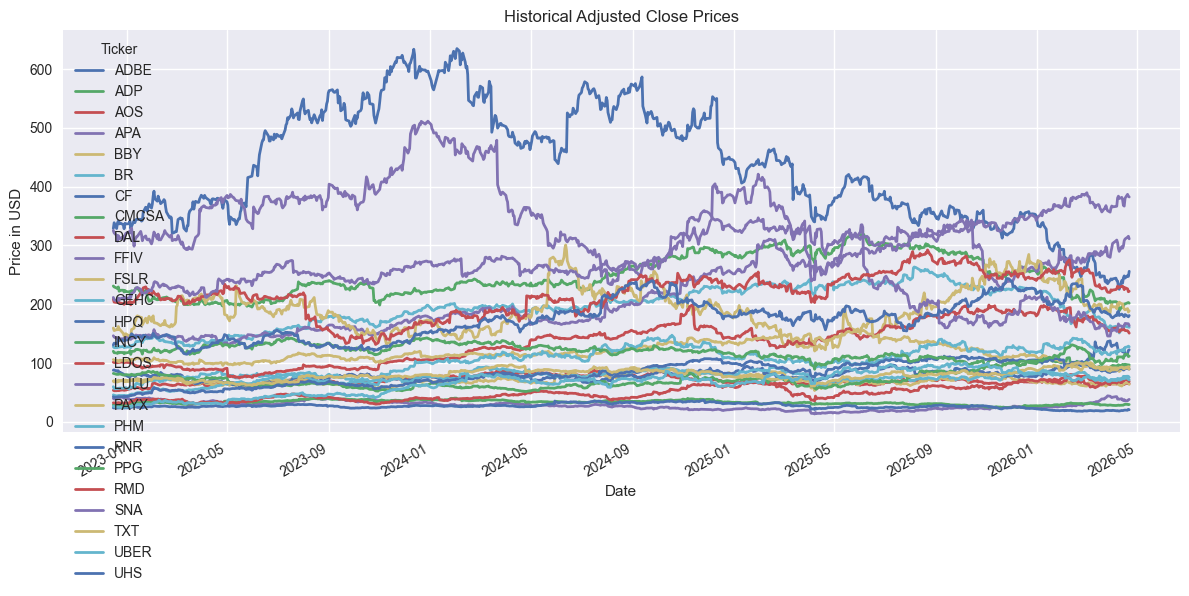

In [23]:
ax = prices.plot(figsize=(12, 6), linewidth=2)
ax.set_title("Historical Adjusted Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price in USD")
ax.legend(title="Ticker")
plt.tight_layout()
plt.show()

## 6. Compute Daily Returns and Annualized Covariance

Convert prices into daily simple returns and scale the covariance matrix to an annualized basis using 252 trading days.

In [24]:
daily_returns = prices.pct_change().dropna(how="any")
annual_covariance = daily_returns.cov() * trading_days

print("Daily returns sample:")
display(daily_returns.head())
print("Annualized covariance matrix:")
display(annual_covariance)

Daily returns sample:


Ticker,ADBE,ADP,AOS,APA,BBY,BR,CF,CMCSA,DAL,FFIV,...,LULU,PAYX,PHM,PNR,PPG,RMD,SNA,TXT,UBER,UHS
Date,,,,,,,,,,,,,,,,,,,,,
2022-12-16,0.029905,-0.006994,-0.013204,-0.027969,-0.016093,-0.011929,0.005500,-0.003467,-0.004211,-0.014626,...,-0.012208,-0.009566,-0.015940,-0.024039,-0.020191,-0.024367,-0.020015,0.003872,-0.010290,0.024447
2022-12-19,-0.028889,-0.008055,0.000178,0.001142,0.004026,-0.001050,-0.024718,-0.014787,-0.005739,-0.016994,...,-0.013448,-0.003794,-0.026350,0.008978,-0.004280,-0.003098,-0.007044,-0.010286,-0.039276,-0.009354
2022-12-20,0.028775,-0.004693,0.004995,0.006615,-0.007017,0.001501,0.008951,0.012655,-0.000607,0.008820,...,-0.030923,-0.010907,-0.006655,-0.003879,-0.006925,-0.001147,0.002409,0.003753,0.000401,0.008104
2022-12-21,0.009343,0.012833,0.015975,0.057557,0.017542,0.021887,-0.000214,0.019471,0.023404,-0.006015,...,0.031323,0.004463,0.021885,0.020385,0.019157,0.005888,0.020341,0.022289,0.016026,0.047275
2022-12-22,-0.014236,-0.031898,-0.017645,-0.042425,-0.002108,-0.014157,-0.038811,-0.007412,-0.022275,-0.014707,...,-0.012029,-0.022567,0.005900,-0.006285,-0.010146,-0.004759,-0.017318,-0.014348,-0.028391,-0.007113


Annualized covariance matrix:


Ticker,ADBE,ADP,AOS,APA,BBY,BR,CF,CMCSA,DAL,FFIV,...,LULU,PAYX,PHM,PNR,PPG,RMD,SNA,TXT,UBER,UHS
Ticker,,,,,,,,,,,,,,,,,,,,,
ADBE,0.114018,0.024373,0.018709,0.018022,0.024682,0.024109,0.008712,0.020386,0.034544,0.033420,...,0.038468,0.026728,0.021213,0.027604,0.022768,0.020664,0.015306,0.021522,0.036573,0.014411
ADP,0.024373,0.039260,0.015496,0.016436,0.018284,0.023514,0.009275,0.015287,0.020083,0.019206,...,0.021358,0.036634,0.012353,0.020760,0.015894,0.015638,0.015427,0.014691,0.018598,0.011583
AOS,0.018709,0.015496,0.066402,0.022715,0.030439,0.017227,0.007480,0.018157,0.035340,0.020826,...,0.032125,0.019927,0.047442,0.039621,0.036857,0.019228,0.030864,0.031599,0.022302,0.020005
APA,0.018022,0.016436,0.022715,0.194637,0.051474,0.014080,0.061987,0.024259,0.039485,0.032310,...,0.030525,0.023015,0.026128,0.034557,0.026393,0.016892,0.025794,0.038758,0.028989,0.015762
BBY,0.024682,0.018284,0.030439,0.051474,0.120086,0.020305,0.017227,0.026536,0.062522,0.034649,...,0.048768,0.022501,0.044166,0.044850,0.039460,0.027011,0.028397,0.034364,0.034197,0.025808
BR,0.024109,0.023514,0.017227,0.014080,0.020305,0.046195,0.007173,0.013522,0.019920,0.020049,...,0.019865,0.026762,0.020044,0.026076,0.018697,0.016952,0.016029,0.016221,0.027893,0.012719
CF,0.008712,0.009275,0.007480,0.061987,0.017227,0.007173,0.113860,0.008845,0.006210,0.013791,...,0.007931,0.011173,0.004807,0.009448,0.003144,0.002061,0.009368,0.014631,0.014383,0.010706
CMCSA,0.020386,0.015287,0.018157,0.024259,0.026536,0.013522,0.008845,0.062486,0.028026,0.018260,...,0.019113,0.018818,0.020728,0.021691,0.023400,0.014127,0.016242,0.023838,0.013518,0.016017
DAL,0.034544,0.020083,0.035340,0.039485,0.062522,0.019920,0.006210,0.028026,0.154492,0.042903,...,0.055469,0.025151,0.045520,0.052831,0.049877,0.024688,0.034388,0.043067,0.050534,0.027020


## 7. Calculate Equal-Weight Baseline Portfolio Metrics

Use equal weights of $1/n$ to build a baseline portfolio and compute return, volatility, and variance for comparison with the optimized solution.

In [25]:
asset_count = len(prices.columns)
equal_weights = np.repeat(1 / asset_count, asset_count)

annual_asset_returns = daily_returns.mean() * trading_days
baseline_return = float(np.dot(equal_weights, annual_asset_returns))
baseline_variance = float(equal_weights.T @ annual_covariance.values @ equal_weights)
baseline_volatility = float(np.sqrt(baseline_variance))

print("Equal-weight baseline metrics")
print(f"Expected annual return: {baseline_return:.2%}")
print(f"Annual volatility: {baseline_volatility:.2%}")
print(f"Annual variance: {baseline_variance:.2%}")

Equal-weight baseline metrics
Expected annual return: 12.03%
Annual volatility: 16.60%
Annual variance: 2.76%


## 8. Optimize Portfolio Weights for Maximum Sharpe Ratio

Estimate expected returns and covariance using PyPortfolioOpt, then solve for the maximum-Sharpe allocation.

In [26]:
mu = expected_returns.mean_historical_return(prices)
Sigma = risk_models.sample_cov(prices)

ef = EfficientFrontier(mu, Sigma)
ef.max_sharpe()
cleaned_weights = ef.clean_weights()
optimized_weights = pd.Series(cleaned_weights).sort_values(ascending=False)
optimized_weights

PHM     0.333580
UBER    0.242740
FFIV    0.223530
SNA     0.097450
LDOS    0.056720
CF      0.045980
ADBE    0.000000
TXT     0.000000
RMD     0.000000
PPG     0.000000
PNR     0.000000
PAYX    0.000000
LULU    0.000000
HPQ     0.000000
INCY    0.000000
ADP     0.000000
GEHC    0.000000
FSLR    0.000000
DAL     0.000000
CMCSA   0.000000
BR      0.000000
BBY     0.000000
APA     0.000000
AOS     0.000000
UHS     0.000000
dtype: float64

## 9. Report Optimized Portfolio Performance

Display the optimized weight per ticker and the portfolio-level return, volatility, and Sharpe Ratio metrics.

In [27]:
optimized_performance = ef.portfolio_performance(verbose=False)
optimized_return, optimized_volatility, optimized_sharpe = optimized_performance

print("Optimized portfolio weights")
display((optimized_weights * 100).rename("weight_pct").to_frame().style.format("{:.2f}"))
print(f"Expected annual return: {optimized_return:.2%}")
print(f"Annual volatility: {optimized_volatility:.2%}")
print(f"Sharpe Ratio: {optimized_sharpe:.2f}")

Optimized portfolio weights


,weight_pct
PHM,33.36
UBER,24.27
FFIV,22.35
SNA,9.74
LDOS,5.67
CF,4.60
ADBE,0.00
TXT,0.00
RMD,0.00
PPG,0.00


Expected annual return: 29.91%
Annual volatility: 20.51%
Sharpe Ratio: 1.46


## 10. Allocate Discrete Shares From a Cash Budget

Translate the optimized weights into whole-share purchases using the latest available prices and report the leftover cash balance.

In [28]:
latest_prices = get_latest_prices(prices)
allocator = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=portfolio_budget)
allocation, leftover_cash = allocator.lp_portfolio()

allocation_series = pd.Series(allocation, name="shares").sort_values(ascending=False)

print("Discrete allocation")
display(allocation_series.to_frame())
print(f"Leftover cash: ${leftover_cash:,.2f}")

Discrete allocation


,shares
UBER,47
PHM,39
FFIV,11
LDOS,6
CF,5
SNA,4


Leftover cash: $3.84
